# Consistent Hashing with Binary Search

## Traditional Hashing

In [45]:
import requests

class StorageNode:
    def __init__(self, name=None, host=None):
        self.name = name
        self.host = host
        
    def fetch_file(self, path):
        return requests.get(f'https://{self.host}:1231/{path}').text
    
    def put_file(self, path):
        with open(path, 'r') as fp:
            content = fp.read()
            return requests.post(f'https://{self.host}:1231/{path}', body=content).text

In [46]:
# storage_nodes holding instances of actual storage node objects
storage_nodes = [
    StorageNode(name='A', host='239.67.52.72'),
    StorageNode(name='B', host='137.70.131.229'),
    StorageNode(name='C', host='98.5.87.182'),
    StorageNode(name='D', host='11.225.158.95'),
    StorageNode(name='E', host='203.187.116.210'),
]


def hash_fn(key):
    """The function sums the bytes present in the `key` and then
    take a mod with 5. This hash function thus generates output
    in the range [0, 4].
    """
    return sum(bytearray(key.encode('utf-8'))) % 5

In [47]:
def upload(path):
    # we use the hash function to get the index of the storage node
    # that would hold the file
    index = hash_fn(path)

    # we get the StorageNode instance
    node = storage_nodes[index]

    # we put the file on the node and return
    return node.put_file(path)


def fetch(path):
    # we use the hash function to get the index of the storage node
    # that would hold the file
    index = hash_fn(path)

    # we get the StorageNode instance
    node = storage_nodes[index]

    # we fetch the file from the node and return
    return node.fetch_file(path)

In [48]:
# Now we find where the 5 files 'f1.txt', 'f2.txt', 'f3.txt', 'f4.txt', 'f5.txt'
# reside on the storage nodes.

for file in ['f1.txt', 'f2.txt', 'f3.txt', 'f4.txt', 'f5.txt']:
    print(f"file {file} resides on node {storage_nodes[hash_fn(file)].name}")

file f1.txt resides on node E
file f2.txt resides on node A
file f3.txt resides on node B
file f4.txt resides on node C
file f5.txt resides on node D


### Scaling up the Storage Nodes

Now say we scale up and want to add 2 more storage instances i.e. from 5 we will now have 7 storage nodes, so the hash function instead of doing `mod 5` will now perform `mod 7`.

In [49]:
# storage_nodes holding instances of actual storage node objects
storage_nodes = [
    StorageNode(name='A', host='239.67.52.72'),
    StorageNode(name='B', host='137.70.131.229'),
    StorageNode(name='C', host='98.5.87.182'),
    StorageNode(name='D', host='11.225.158.95'),
    StorageNode(name='E', host='203.187.116.210'),
    StorageNode(name='F', host='107.117.238.203'),
    StorageNode(name='G', host='27.161.219.131'),
]

def hash_fn(key):
    """The function sums the bytes present in the `key` and then
    take a mod with 7. This hash function thus generates output
    in the range [0, 6].
    """
    return sum(bytearray(key.encode('utf-8'))) % 7

In [50]:
# Now we find where the 5 files 'f1.txt', 'f2.txt', 'f3.txt', 'f4.txt', 'f5.txt'
# reside on the storage nodes.

for file in ['f1.txt', 'f2.txt', 'f3.txt', 'f4.txt', 'f5.txt']:
    print(f"file {file} resides on node {storage_nodes[hash_fn(file)].name}")

file f1.txt resides on node D
file f2.txt resides on node E
file f3.txt resides on node F
file f4.txt resides on node G
file f5.txt resides on node A


## Consistent Hashing

In [51]:
import hashlib
from typing import Union
from bisect import bisect, bisect_left, bisect_right

from plot import plot_hashring

In [52]:
def hash_fn(key: str, total_slots: int) -> int:
    """hash_fn creates an integer equivalent of a SHA256 hash and
    takes a modulo with the total number of slots in hash space.
    """
    hsh = hashlib.sha256()

    # converting data into bytes and passing it to hash function
    hsh.update(bytes(key.encode('utf-8')))

    # converting the HEX digest into equivalent integer value
    return int(hsh.hexdigest(), 16) % total_slots

In [53]:
class ConsistentHash:
    """ConsistentHash represents an array based implementation of
    consistent hashing algorithm.
    """

    def __init__(self):
        self._keys = []           # indices taken up in the ring
        self.nodes = []           # nodes present in the ring. nodes[i] is present at index keys[i]
        self.total_slots = 50     # total slots in the ring

    def add_node(self, node: StorageNode) -> int:
        """add_node function adds a new node in the system and returns the key
        from the hash space where it was placed
        """

        # handling error when hash space is full.
        if len(self._keys) == self.total_slots:
            raise Exception("hash space is full")

        key = hash_fn(node.host, self.total_slots)

        # find the index where the key should be inserted in the keys array
        # this will be the index where the Storage Node will be added in the
        # nodes array.
        index = bisect(self._keys, key)

        # if we have already seen the key i.e. node already is present
        # for the same key, we raise Collision Exception
        if index > 0 and self._keys[index - 1] == key:
            raise Exception("collision occurred")

        # insert the node_id and the key at the same `index` location.
        # this insertion will keep nodes and keys sorted w.r.t keys.
        self.nodes.insert(index, node)
        self._keys.insert(index, key)

        return key

    def remove_node(self, node: StorageNode) -> int:
        """remove_node removes the node and returns the key
        from the hash space on which the node was placed.
        """

        # handling error when space is empty
        if len(self._keys) == 0:
            raise Exception("hash space is empty")

        key = hash_fn(node.host, self.total_slots)

        # we find the index where the key would reside in the keys
        index = bisect_left(self._keys, key)

        # if key does not exist in the array we raise Exception
        if index >= len(self._keys) or self._keys[index] != key:
            raise Exception("node does not exist")

        # now that all sanity checks are done we popping the
        # keys and nodes at the index and thus removing presence of the node.
        self._keys.pop(index)
        self.nodes.pop(index)

        return key

    def assign(self, item: str) -> str:
        """Given an item, the function returns the node it is associated with.
        """
        key = hash_fn(item, self.total_slots)

        # we find the first node to the right of this key
        # if bisect_right returns index which is out of bounds then
        # we circle back to the first in the array in a circular fashion.
        index = bisect_right(self._keys, key) % len(self._keys)

        # return the node present at the index
        return self.nodes[index]

    def plot(self, item: str = None, node: StorageNode = None) -> None:
        plot_hashring(
            self.total_slots,
            self._keys,
            self.nodes,
            item_key=hash_fn(item, self.total_slots) if item else None,
            node_key=hash_fn(node.host, self.total_slots) if node else None,
        )

In [54]:
ch = ConsistentHash()

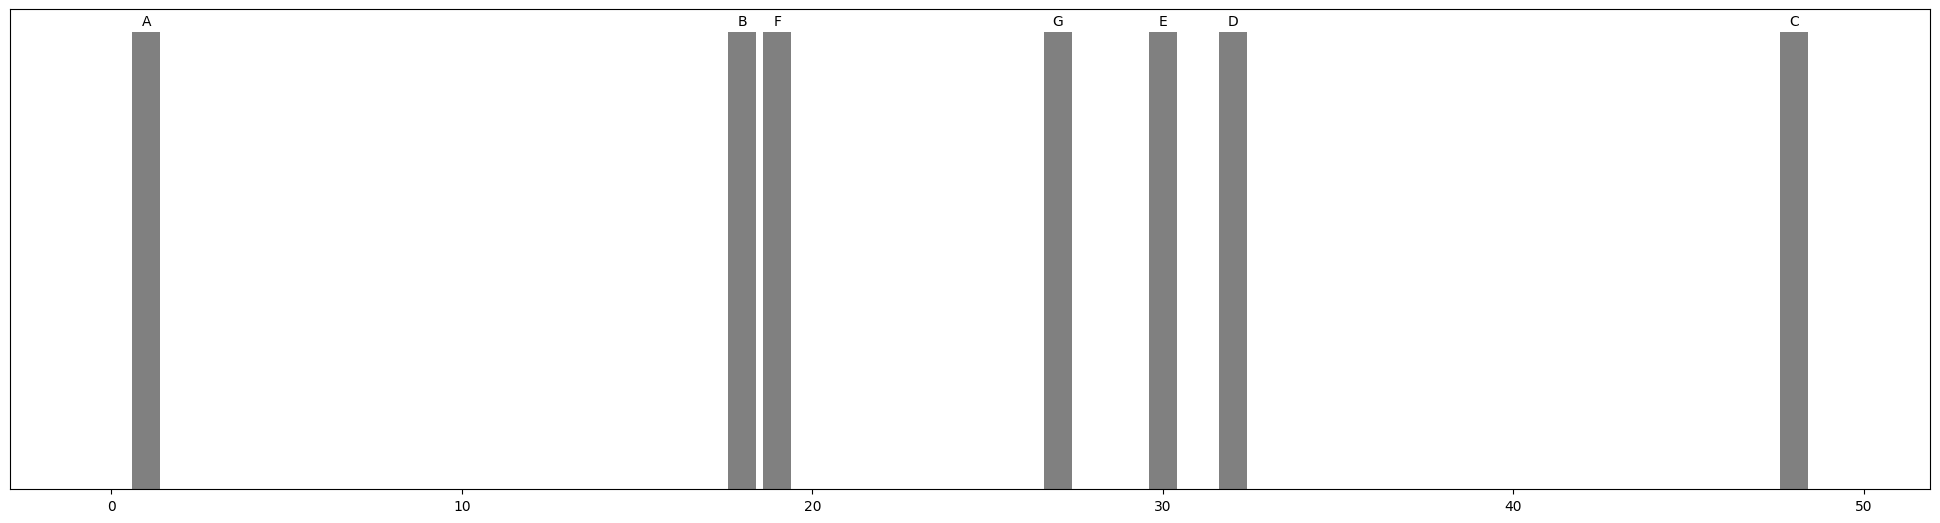

In [55]:
for node in storage_nodes:
    ch.add_node(node)
ch.plot()

file f1.txt (shown in green) resides on node E (shown in red)


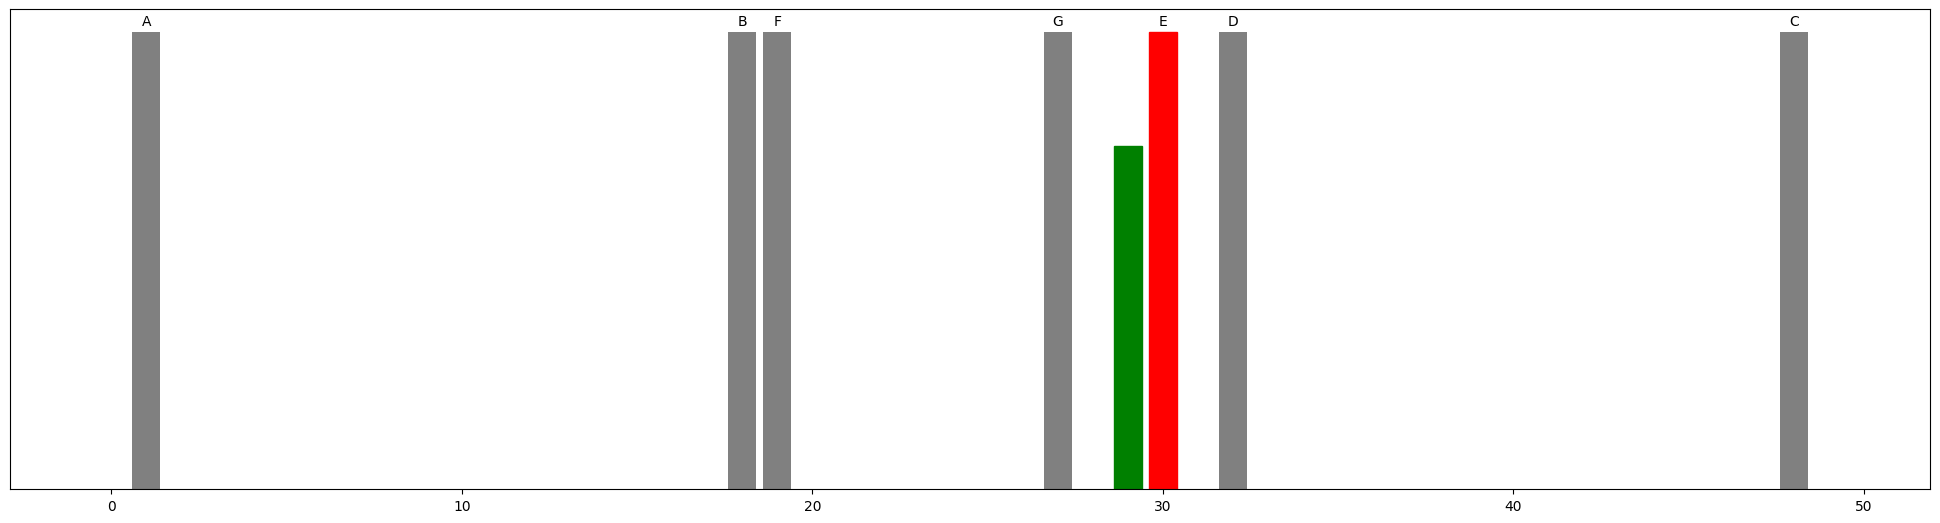

file f2.txt (shown in green) resides on node B (shown in red)


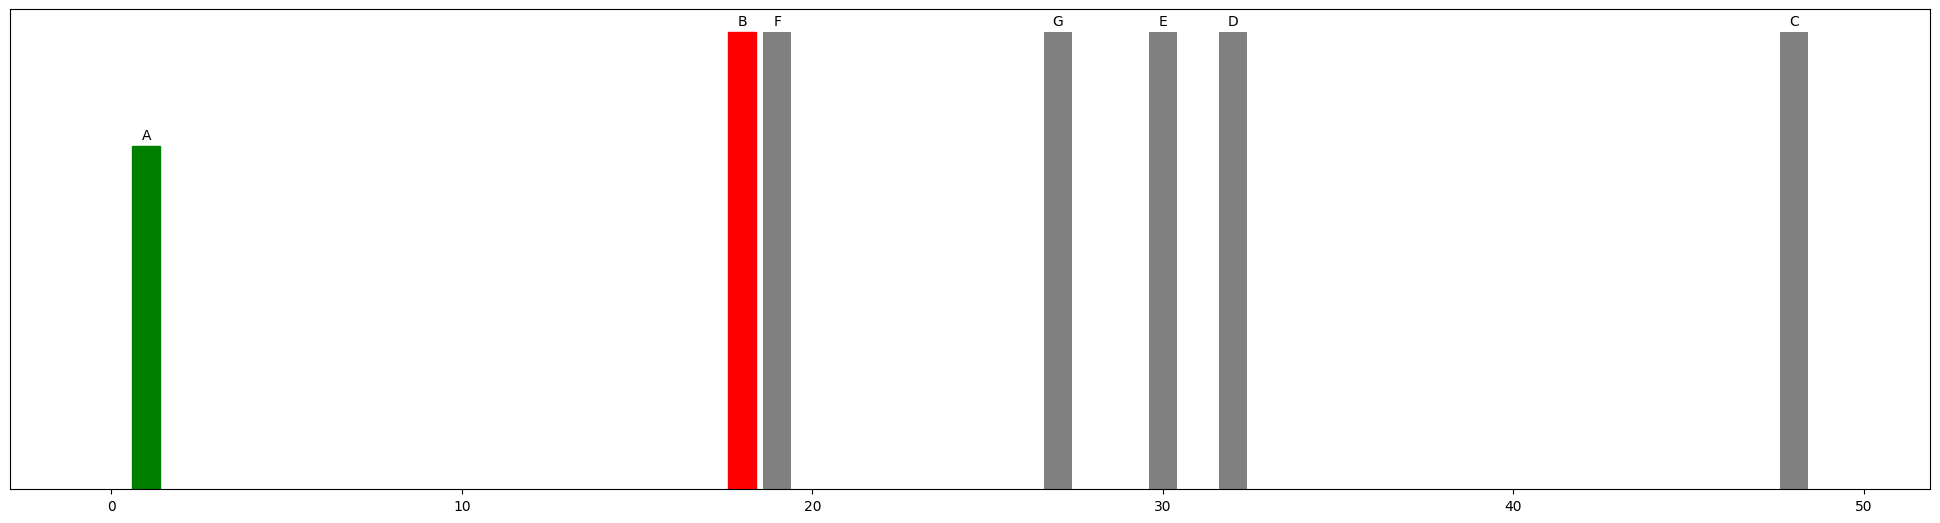

file f3.txt (shown in green) resides on node B (shown in red)


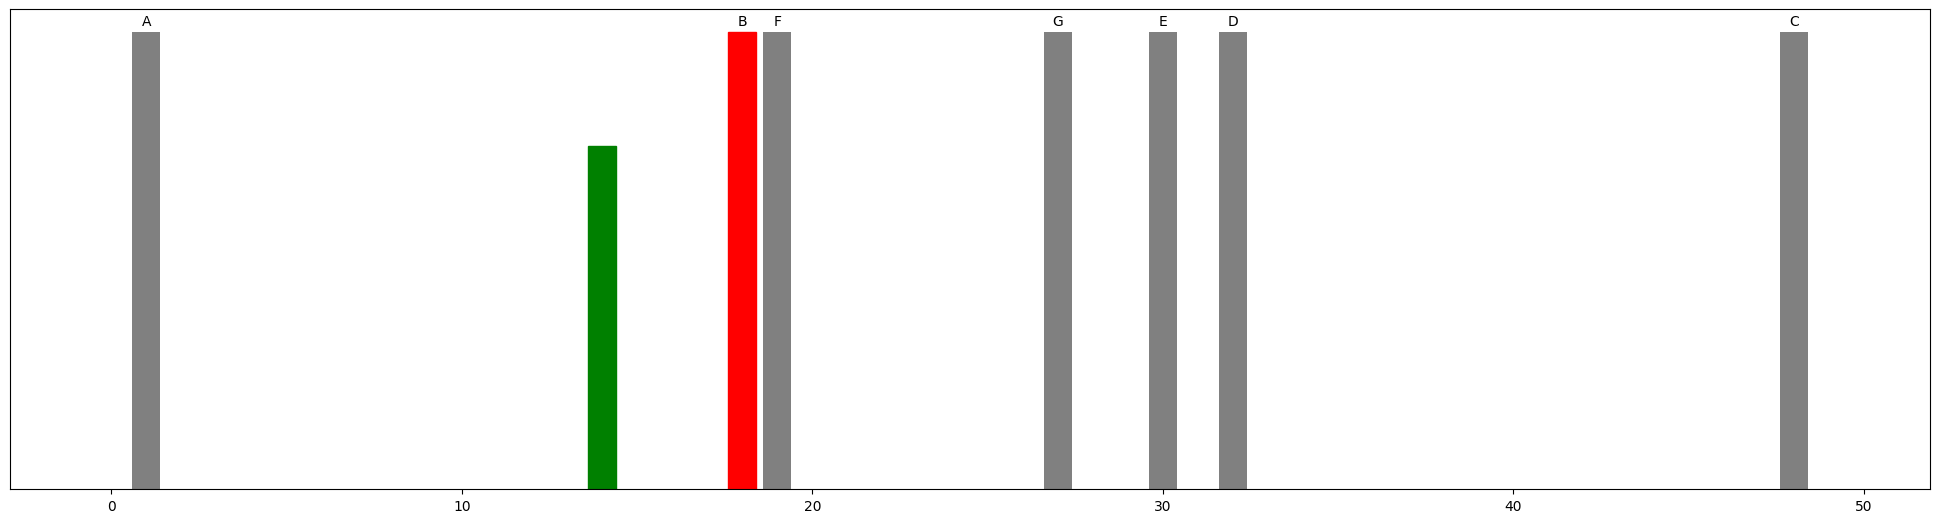

file f4.txt (shown in green) resides on node C (shown in red)


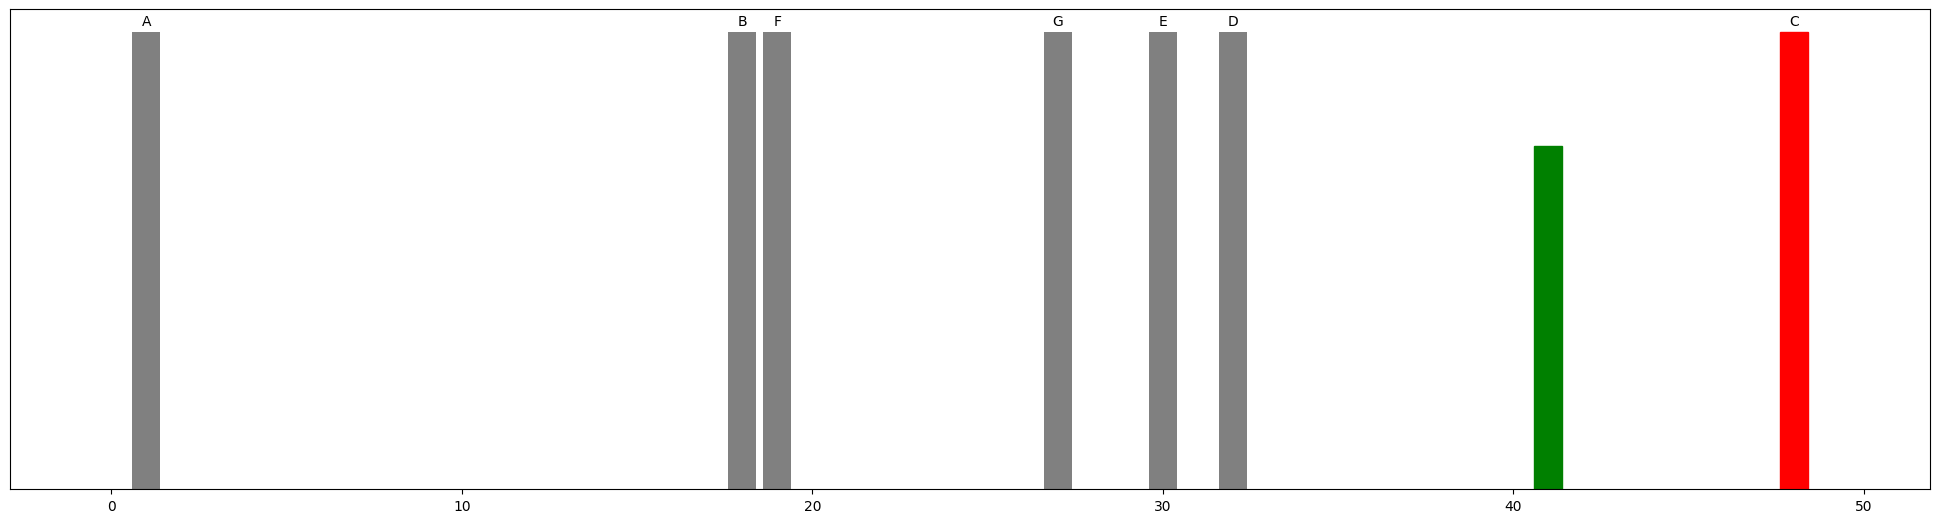

file f5.txt (shown in green) resides on node G (shown in red)


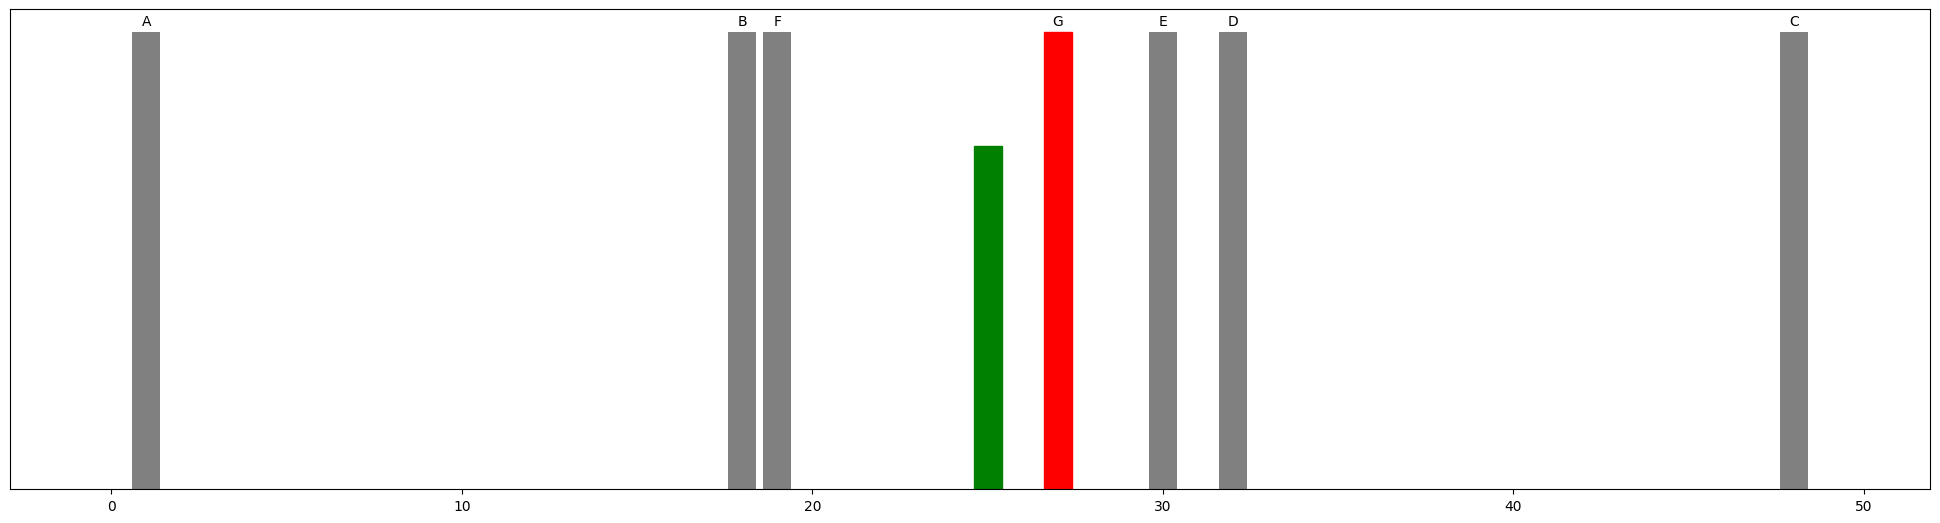

In [56]:
for file in ['f1.txt', 'f2.txt', 'f3.txt', 'f4.txt', 'f5.txt']:
    print(f"file {file} (shown in green) resides on node {ch.assign(file).name} (shown in red)")
    ch.plot(file, ch.assign(file))

### Migration when a node is added

When a new node is added to the ring, only the keys that fall between the new node and its predecessor need to migrate. All other keys stay on the same node. Let's see this in action.

In [57]:
# Step 1: Record current file → node assignments BEFORE adding a node
files = [f'f{i}.txt' for i in range(1, 21)]  # use more files to see the effect clearly

before_add = {f: ch.assign(f).name for f in files}
print("=== Assignments BEFORE adding node H ===")
for f, n in before_add.items():
    print(f"  {f} → node {n}")

=== Assignments BEFORE adding node H ===
  f1.txt → node E
  f2.txt → node B
  f3.txt → node B
  f4.txt → node C
  f5.txt → node G
  f6.txt → node B
  f7.txt → node C
  f8.txt → node B
  f9.txt → node A
  f10.txt → node B
  f11.txt → node B
  f12.txt → node B
  f13.txt → node G
  f14.txt → node B
  f15.txt → node C
  f16.txt → node G
  f17.txt → node G
  f18.txt → node B
  f19.txt → node A
  f20.txt → node G


=== Assignments AFTER adding node H ===
  f1.txt → node E
  f2.txt → node H
  f3.txt → node H
  f4.txt → node C
  f5.txt → node G
  f6.txt → node H
  f7.txt → node C
  f8.txt → node B
  f9.txt → node A
  f10.txt → node H
  f11.txt → node H
  f12.txt → node H
  f13.txt → node G
  f14.txt → node H
  f15.txt → node C
  f16.txt → node G
  f17.txt → node G
  f18.txt → node H
  f19.txt → node A
  f20.txt → node G

🔀 Migrated: 8 out of 20 files (40.0%)
  f2.txt: node B → node H
  f3.txt: node B → node H
  f6.txt: node B → node H
  f10.txt: node B → node H
  f11.txt: node B → node H
  f12.txt: node B → node H
  f14.txt: node B → node H
  f18.txt: node B → node H

✅ Stayed:   12 out of 20 files (60.0%)
  f1.txt: node E (unchanged)
  f4.txt: node C (unchanged)
  f5.txt: node G (unchanged)
  f7.txt: node C (unchanged)
  f8.txt: node B (unchanged)
  f9.txt: node A (unchanged)
  f13.txt: node G (unchanged)
  f15.txt: node C (unchanged)
  f16.txt: node G (unchanged)
  f17.txt: node G (unchanged)
  f

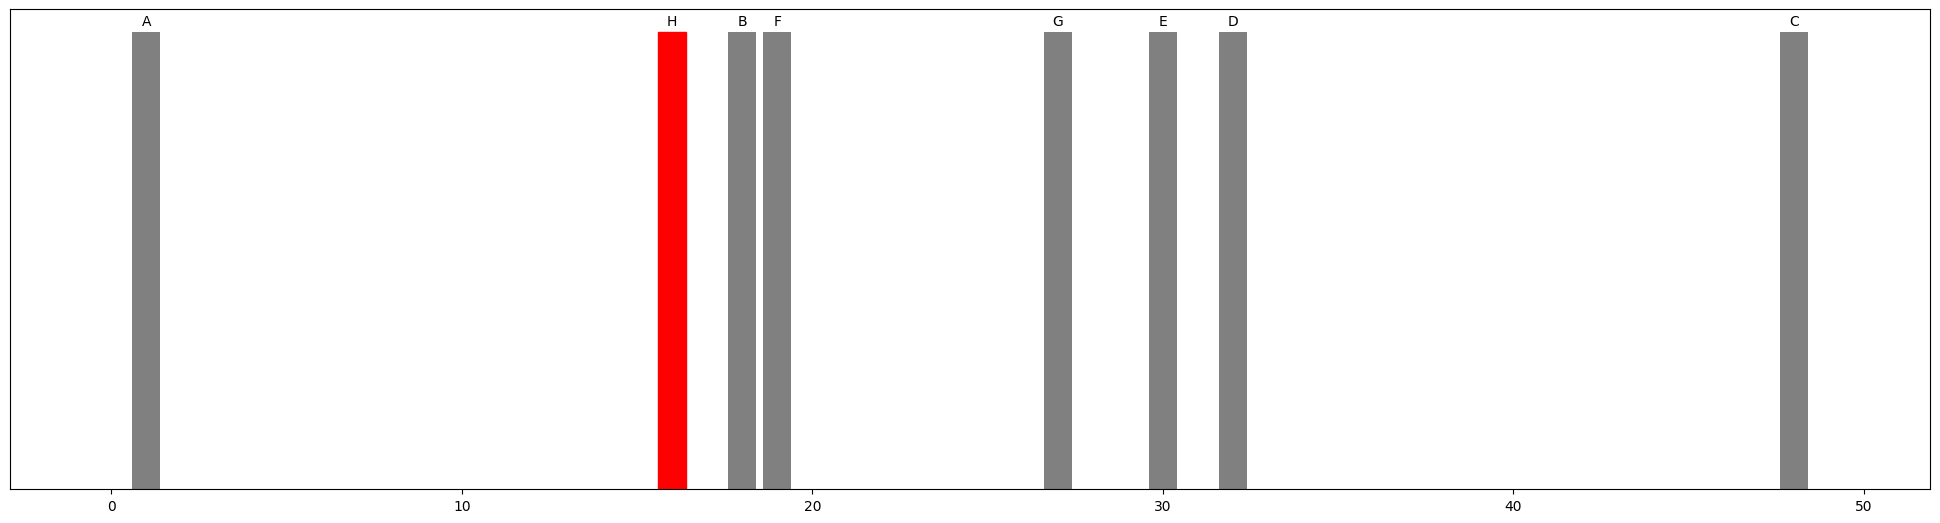

In [58]:
# Step 2: Add a new node H and record assignments AFTER
new_node = StorageNode(name='H', host='52.45.200.61')
ch.add_node(new_node)

after_add = {f: ch.assign(f).name for f in files}
print("=== Assignments AFTER adding node H ===")
for f, n in after_add.items():
    print(f"  {f} → node {n}")

# Step 3: Show which files migrated
migrated = {f: (before_add[f], after_add[f]) for f in files if before_add[f] != after_add[f]}
stayed   = {f: before_add[f] for f in files if before_add[f] == after_add[f]}

print(f"\n🔀 Migrated: {len(migrated)} out of {len(files)} files ({100*len(migrated)/len(files):.1f}%)")
for f, (old, new) in migrated.items():
    print(f"  {f}: node {old} → node {new}")

print(f"\n✅ Stayed:   {len(stayed)} out of {len(files)} files ({100*len(stayed)/len(files):.1f}%)")
for f, n in stayed.items():
    print(f"  {f}: node {n} (unchanged)")

ch.plot(node=new_node)

### Migration when a node is removed

Similarly, when a node is removed, only the keys that were assigned to that node need to migrate — they move to the next node clockwise on the ring. All other assignments remain untouched.

In [59]:
# Step 1: Record current assignments BEFORE removing a node
before_remove = {f: ch.assign(f).name for f in files}
print("=== Assignments BEFORE removing node C ===")
for f, n in before_remove.items():
    print(f"  {f} → node {n}")

=== Assignments BEFORE removing node C ===
  f1.txt → node E
  f2.txt → node H
  f3.txt → node H
  f4.txt → node C
  f5.txt → node G
  f6.txt → node H
  f7.txt → node C
  f8.txt → node B
  f9.txt → node A
  f10.txt → node H
  f11.txt → node H
  f12.txt → node H
  f13.txt → node G
  f14.txt → node H
  f15.txt → node C
  f16.txt → node G
  f17.txt → node G
  f18.txt → node H
  f19.txt → node A
  f20.txt → node G


=== Assignments AFTER removing node C ===
  f1.txt → node E
  f2.txt → node H
  f3.txt → node H
  f4.txt → node A
  f5.txt → node G
  f6.txt → node H
  f7.txt → node A
  f8.txt → node B
  f9.txt → node A
  f10.txt → node H
  f11.txt → node H
  f12.txt → node H
  f13.txt → node G
  f14.txt → node H
  f15.txt → node A
  f16.txt → node G
  f17.txt → node G
  f18.txt → node H
  f19.txt → node A
  f20.txt → node G

🔀 Migrated: 3 out of 20 files (15.0%)
  f4.txt: node C → node A
  f7.txt: node C → node A
  f15.txt: node C → node A

✅ Stayed:   17 out of 20 files (85.0%)
  f1.txt: node E (unchanged)
  f2.txt: node H (unchanged)
  f3.txt: node H (unchanged)
  f5.txt: node G (unchanged)
  f6.txt: node H (unchanged)
  f8.txt: node B (unchanged)
  f9.txt: node A (unchanged)
  f10.txt: node H (unchanged)
  f11.txt: node H (unchanged)
  f12.txt: node H (unchanged)
  f13.txt: node G (unchanged)
  f14.txt: node H (unchanged)
  f16.txt: node G (unchanged)
  f17.txt: node G (unchanged)
  f18.txt: node 

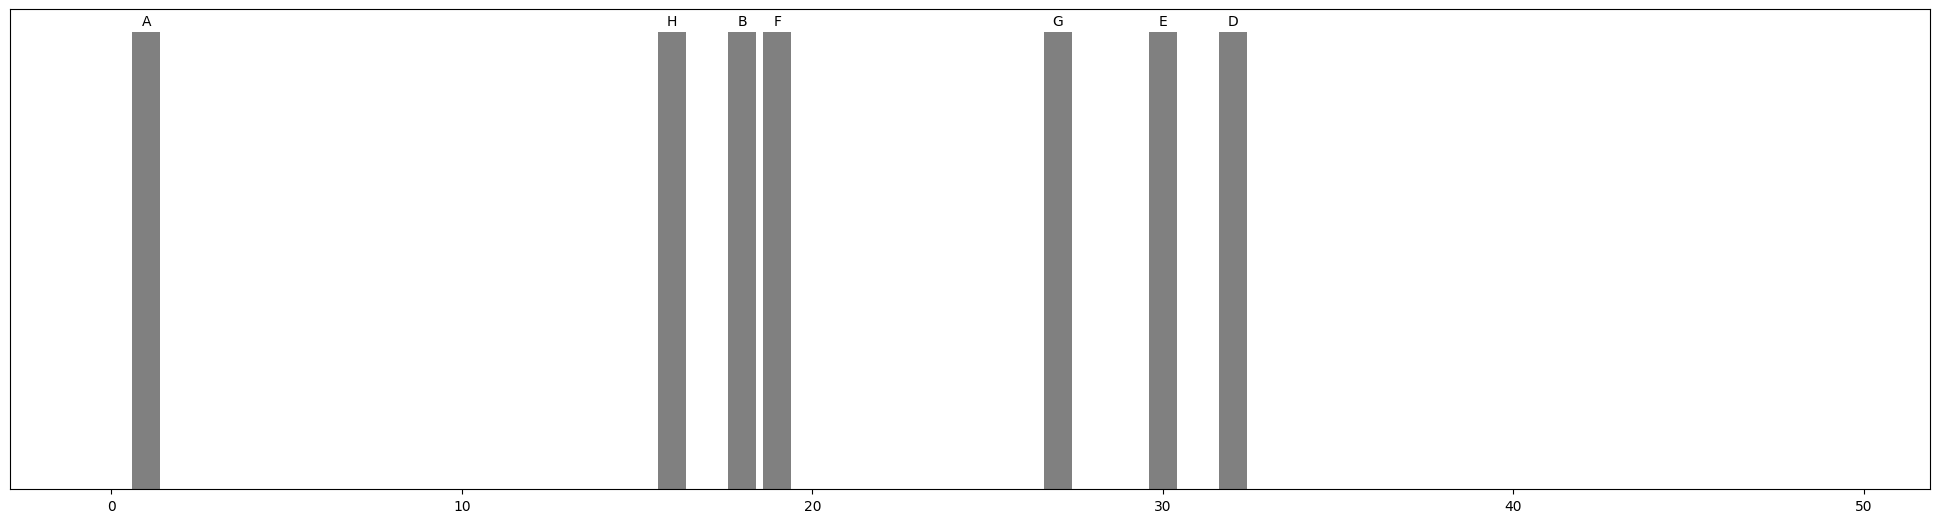

In [60]:
# Step 2: Remove node C and record assignments AFTER
removed_node = storage_nodes[2]  # node C
ch.remove_node(removed_node)

after_remove = {f: ch.assign(f).name for f in files}
print("=== Assignments AFTER removing node C ===")
for f, n in after_remove.items():
    print(f"  {f} → node {n}")

# Step 3: Show which files migrated
migrated = {f: (before_remove[f], after_remove[f]) for f in files if before_remove[f] != after_remove[f]}
stayed   = {f: before_remove[f] for f in files if before_remove[f] == after_remove[f]}

print(f"\n🔀 Migrated: {len(migrated)} out of {len(files)} files ({100*len(migrated)/len(files):.1f}%)")
for f, (old, new) in migrated.items():
    print(f"  {f}: node {old} → node {new}")

print(f"\n✅ Stayed:   {len(stayed)} out of {len(files)} files ({100*len(stayed)/len(files):.1f}%)")
for f, n in stayed.items():
    print(f"  {f}: node {n} (unchanged)")

ch.plot()

### Key takeaway

With consistent hashing, adding or removing a node only causes **a fraction** of keys to migrate (roughly $\frac{K}{N}$ where $K$ is the number of keys and $N$ is the number of nodes). Compare this to traditional hashing where changing the number of nodes causes **almost all** keys to be remapped.

### Who is responsible for knowing all the files?

In our demo above, we "cheated" — we had a **global list of files** and re-checked every one of them. But in a real distributed system, **no single entity knows all the files**. Instead:

- **Each node knows only its own data.** Node A knows the files stored on A, Node B knows files on B, etc.
- **The hash ring only knows which nodes exist** and where they sit on the ring — it does NOT track individual files.

So when a node is added or removed, migration works like this:

| Event | Who acts? | What happens? |
|-------|-----------|---------------|
| **Node added** | The **new node** contacts its **successor** (next node clockwise) | The successor scans its own data and transfers keys that now belong to the new node (keys between the new node's predecessor and itself) |
| **Node removed** | The **departing node** (or the system if it crashed) | The departing node transfers all its data to its **successor**. If it crashed, replicas on other nodes are used to recover |

Let's simulate this realistically — each node tracks its own files, and migration is handled by the **affected neighbor** only.

In [61]:
class RealisticConsistentHash:
    """A more realistic consistent hash where each NODE tracks its own data.
    There is no global file list — migration is handled by neighbor nodes.
    """

    def __init__(self):
        self._keys = []
        self.nodes = []
        self.total_slots = 50
        # Each node stores its own set of files — no global registry!
        self.node_data = {}  # node_name -> set of file names

    def add_node(self, node: StorageNode) -> dict:
        if len(self._keys) == self.total_slots:
            raise Exception("hash space is full")

        key = hash_fn(node.host, self.total_slots)
        index = bisect(self._keys, key)
        if index > 0 and self._keys[index - 1] == key:
            raise Exception("collision occurred")

        self.nodes.insert(index, node)
        self._keys.insert(index, key)
        self.node_data[node.name] = set()

        # === MIGRATION LOGIC ===
        # The SUCCESSOR node (next clockwise) checks its own data
        # and transfers files that now hash to the new node.
        successor_index = (index + 1) % len(self._keys)
        successor = self.nodes[successor_index]
        migrated = {}

        if successor.name != node.name and successor.name in self.node_data:
            files_to_migrate = set()
            for f in self.node_data[successor.name]:
                if self.assign(f).name == node.name:
                    files_to_migrate.add(f)

            # Successor transfers these files to the new node
            for f in files_to_migrate:
                self.node_data[successor.name].remove(f)
                self.node_data[node.name].add(f)

            if files_to_migrate:
                migrated[successor.name] = files_to_migrate

        return migrated

    def remove_node(self, node: StorageNode) -> dict:
        if len(self._keys) == 0:
            raise Exception("hash space is empty")

        key = hash_fn(node.host, self.total_slots)
        index = bisect_left(self._keys, key)
        if index >= len(self._keys) or self._keys[index] != key:
            raise Exception("node does not exist")

        # === MIGRATION LOGIC ===
        # The DEPARTING node transfers ALL its files to its successor
        successor_index = (index + 1) % len(self._keys)
        # If we're removing the last element, successor wraps to 0
        if successor_index == index:
            raise Exception("cannot remove the only node")

        successor = self.nodes[successor_index]
        migrated = {}

        departing_files = self.node_data.pop(node.name, set())
        if departing_files:
            self.node_data[successor.name].update(departing_files)
            migrated[successor.name] = departing_files

        self._keys.pop(index)
        self.nodes.pop(index)

        return migrated

    def assign(self, item: str) -> StorageNode:
        key = hash_fn(item, self.total_slots)
        index = bisect_right(self._keys, key) % len(self._keys)
        return self.nodes[index]

    def put(self, filename: str):
        """Store a file — the node it hashes to is the one that remembers it."""
        node = self.assign(filename)
        self.node_data[node.name].add(filename)
        return node

    def print_node_contents(self):
        """Each node reports what IT knows about — printed in hash-ring key order."""
        print("📦 Each node's local storage (in ring order):")
        for key, node in zip(self._keys, self.nodes):
            files = sorted(self.node_data.get(node.name, set()))
            print(f"  Node {node.name} (key {key:>2}): {files if files else '(empty)'}")
        print()

In [62]:
# Set up the ring with the original nodes and store some files
rch = RealisticConsistentHash()
for node in storage_nodes:
    rch.add_node(node)

# Store 20 files — each file goes to the node it hashes to
# and THAT NODE remembers it (no global list!)
for i in range(1, 21):
    node = rch.put(f'f{i}.txt')
    print(f"  f{i}.txt → stored on node {node.name}")

print()
rch.print_node_contents()

  f1.txt → stored on node E
  f2.txt → stored on node B
  f3.txt → stored on node B
  f4.txt → stored on node C
  f5.txt → stored on node G
  f6.txt → stored on node B
  f7.txt → stored on node C
  f8.txt → stored on node B
  f9.txt → stored on node A
  f10.txt → stored on node B
  f11.txt → stored on node B
  f12.txt → stored on node B
  f13.txt → stored on node G
  f14.txt → stored on node B
  f15.txt → stored on node C
  f16.txt → stored on node G
  f17.txt → stored on node G
  f18.txt → stored on node B
  f19.txt → stored on node A
  f20.txt → stored on node G

📦 Each node's local storage (in ring order):
  Node A (key  1): ['f19.txt', 'f9.txt']
  Node B (key 18): ['f10.txt', 'f11.txt', 'f12.txt', 'f14.txt', 'f18.txt', 'f2.txt', 'f3.txt', 'f6.txt', 'f8.txt']
  Node F (key 19): (empty)
  Node G (key 27): ['f13.txt', 'f16.txt', 'f17.txt', 'f20.txt', 'f5.txt']
  Node E (key 30): ['f1.txt']
  Node D (key 32): (empty)
  Node C (key 48): ['f15.txt', 'f4.txt', 'f7.txt']



In [63]:
# ADD a node: only the SUCCESSOR scans its own data and transfers what belongs to the new node
print("=" * 60)
print("ADDING node H — only the successor needs to act")
print("=" * 60)

new_node = StorageNode(name='H', host='52.45.200.61')
migrated = rch.add_node(new_node)

if migrated:
    for donor, files in migrated.items():
        print(f"\n  Node {donor} (successor) scanned its OWN files")
        print(f"  and transferred {len(files)} file(s) to new node H:")
        for f in sorted(files):
            print(f"    📤 {f}: node {donor} → node H")
else:
    print("\n  No files needed to migrate!")

print()
rch.print_node_contents()

ADDING node H — only the successor needs to act

  Node B (successor) scanned its OWN files
  and transferred 8 file(s) to new node H:
    📤 f10.txt: node B → node H
    📤 f11.txt: node B → node H
    📤 f12.txt: node B → node H
    📤 f14.txt: node B → node H
    📤 f18.txt: node B → node H
    📤 f2.txt: node B → node H
    📤 f3.txt: node B → node H
    📤 f6.txt: node B → node H

📦 Each node's local storage (in ring order):
  Node A (key  1): ['f19.txt', 'f9.txt']
  Node H (key 16): ['f10.txt', 'f11.txt', 'f12.txt', 'f14.txt', 'f18.txt', 'f2.txt', 'f3.txt', 'f6.txt']
  Node B (key 18): ['f8.txt']
  Node F (key 19): (empty)
  Node G (key 27): ['f13.txt', 'f16.txt', 'f17.txt', 'f20.txt', 'f5.txt']
  Node E (key 30): ['f1.txt']
  Node D (key 32): (empty)
  Node C (key 48): ['f15.txt', 'f4.txt', 'f7.txt']



In [64]:
# REMOVE a node: the departing node transfers ALL its files to its successor
print("=" * 60)
print("REMOVING node C — it transfers all its data to its successor")
print("=" * 60)

node_c = storage_nodes[2]  # node C
migrated = rch.remove_node(node_c)

if migrated:
    for receiver, files in migrated.items():
        print(f"\n  Node C transferred {len(files)} file(s) to node {receiver} (its successor):")
        for f in sorted(files):
            print(f"    📤 {f}: node C → node {receiver}")
else:
    print("\n  Node C had no files — nothing to migrate!")

print()
rch.print_node_contents()

REMOVING node C — it transfers all its data to its successor

  Node C transferred 3 file(s) to node A (its successor):
    📤 f15.txt: node C → node A
    📤 f4.txt: node C → node A
    📤 f7.txt: node C → node A

📦 Each node's local storage (in ring order):
  Node A (key  1): ['f15.txt', 'f19.txt', 'f4.txt', 'f7.txt', 'f9.txt']
  Node H (key 16): ['f10.txt', 'f11.txt', 'f12.txt', 'f14.txt', 'f18.txt', 'f2.txt', 'f3.txt', 'f6.txt']
  Node B (key 18): ['f8.txt']
  Node F (key 19): (empty)
  Node G (key 27): ['f13.txt', 'f16.txt', 'f17.txt', 'f20.txt', 'f5.txt']
  Node E (key 30): ['f1.txt']
  Node D (key 32): (empty)

